In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.neighbors import KernelDensity

from msi.gaussian_mixture.gaussian_mixture_model import ConditionalGMM
from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters

23-08-04 01:09:06    scales.py INF   Setting up healpy to run on 256 CPUs 


In [3]:
method_label = "gaussian_mixture"

# network predictions

### choose a run

In [4]:
base_dir = "/pscratch/sd/a/athomsen/run_files/v3"
# base_dir = "/Users/arne/data/DESY3/models/v3/"

In [5]:
# clustering only
model_dir = "2023-05-30_01-48-23_resnet_vanilla"
n_steps = 50000
params = ["Om", "s8", "bg", "n_bg"]

# with survey systematic correction
_, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = input_output.load_preds(base_dir, model_dir, n_steps)
with h5py.File(os.path.join(base_dir, model_dir, "preds_50000.h5"), "r") as f:
    index_with = f["fiducial/vali/i_example"][:]
i_sorted = np.argsort(index_with)
index_with = index_with[i_sorted]
fidu_vali_preds = fidu_vali_preds[i_sorted]

# without survey systematic correction
# with h5py.File(os.path.join(base_dir, model_dir, "preds_50000_no_survey_systematics.h5"), "r") as f:
with h5py.File(os.path.join(base_dir, model_dir, "preds_50000_no_survey_sys.h5"), "r") as f:
    fidu_vali_preds_without = f["fiducial/vali/pred"][:]
    index_without = f["fiducial/vali/i_example"][:]
    
assert np.all(index_with == index_without), "The example indices must match"
assert np.all(fidu_vali_preds != fidu_vali_preds_without), "The predictions shouldn't be identical"
    
out_dir = os.path.join(base_dir, model_dir)

23-08-04 01:09:07 input_output INF   Array shapes:
 
23-08-04 01:09:07 input_output INF   fidu_train_preds =   (750, 4) 
23-08-04 01:09:07 input_output INF   fidu_vali_preds =    (50, 4) 
23-08-04 01:09:07 input_output INF   grid_preds =         (2499, 16, 4) 
23-08-04 01:09:07 input_output INF   grid_cosmos =        (2499, 4) 
23-08-04 01:09:07 input_output INF   grid_sobol =         (2499, 4) 


### observation

In [13]:
i_obs = 15

obs_incl = fidu_vali_preds[i_obs]
print(obs_incl)

obs_excl = fidu_vali_preds[10]
print(obs_excl)

# obs_excl = fidu_vali_preds_without[i_obs]
# print(obs_excl)

[-0.15662713 -0.3933873  -0.04973077  0.12758961]
[-0.16309161 -0.41526538 -0.00991053  0.13540037]


# Gaussian mixture model

In [14]:
preds = np.concatenate(grid_preds, axis=0)
thetas = np.repeat(grid_cosmos, preds.shape[0]//grid_cosmos.shape[0], axis=0)

print(preds.shape)
print(thetas.shape)

(39984, 4)
(39984, 4)


In [15]:
# p(y | x) <=> p(summary | theta)
model = ConditionalGMM(
    # theta
    x_dim=thetas.shape[1],
    # summary
    y_dim=preds.shape[1],
    out_dir="/pscratch/sd/a/athomsen/run_files/debug/GMM",
    n_gaussians=4,
    u_units=256,
    n_layers=3,
    activation="relu",
    input_noise_sig=0.0,
    tune_hyperparams=False,
)

23-08-04 01:17:36 gaussian_mix INF   Created GMM model with n_params = 214076 
Model: "gaussian_mixture_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise_1 (GaussianN  (None, 4)                0         
 oise)                                                           
                                                                 
 dense_5 (Dense)             (None, 256)               1280      
                                                                 
 dropout_4 (Dropout)         (None, 256)               0         
                                                                 
 dense_6 (Dense)             (None, 256)               65792     
                                                                 
 dropout_5 (Dropout)         (None, 256)               0         
                                                                 
 dense_7 (Dense)             (N

In [16]:
fit_history = model.fit(
    x=thetas,
    y=preds,
    epochs=1000,
    batch_size=2499,
    early_stopping_callback=True,
    learning_rate_callback=True,
)

23-08-04 01:17:36 gaussian_mix INF   Fitted the x and y scalers 


epoch:  35%|███▌      | 353/1000 [00:56<01:31,  7.10it/s, loss=-11.1, val_loss=-10.9, lr=0.000237]

Restoring model weights from the end of the best epoch: 254.


epoch:  35%|███▌      | 354/1000 [00:56<01:28,  7.29it/s, loss=-11.2, val_loss=-10.8, lr=0.000237]

Epoch 354: early stopping


epoch:  35%|███▌      | 354/1000 [00:56<01:43,  6.23it/s, loss=-11.2, val_loss=-10.8, lr=0.000237]

23-08-04 01:18:33 gaussian_mix INF   Finished training 
23-08-04 01:18:33 gaussian_mix INF   Saved the model in /pscratch/sd/a/athomsen/run_files/debug/GMM 


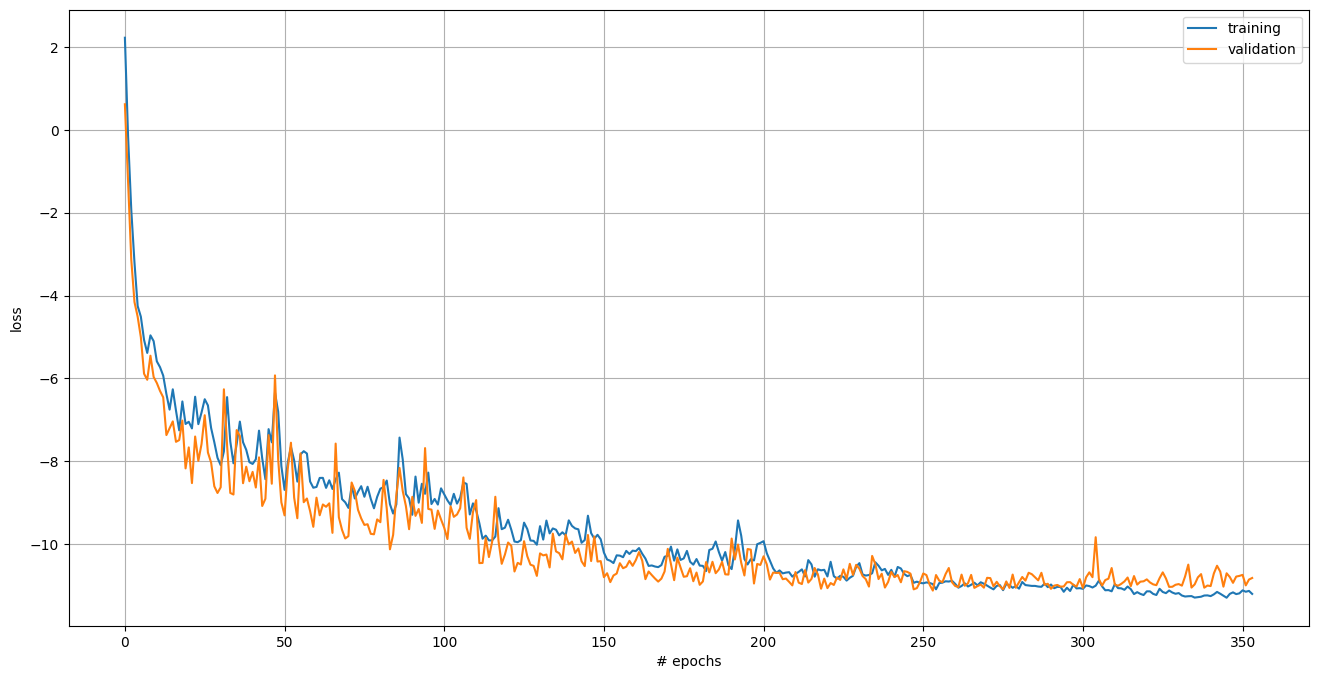

In [17]:
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(fit_history.history["loss"], label="training")
ax.plot(fit_history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="linear")
ax.grid(True)

## MCMC

In [18]:
observations = [obs_incl, obs_excl]
labels = [f"{n_steps}_gmm_incl_survey_sys", f"{n_steps}_gmm_excl_survey_sys"]

for obs, label in zip(observations, labels):
    tf_pred = tf.cast(obs, dtype=tf.float32)
    tf_pred = tf.expand_dims(tf_pred, axis=0)

    def log_likelihood(X): 
        # evaluate the normal distribution
        log_prob = model.log_likelihood(X, tf_pred)

        # enforce the prior
        log_prob = prior.log_posterior(X, log_prob, params=params, conf=None)

        return log_prob
    
    chain = mcmc.run_emcee(
        log_likelihood,
        params,
        out_dir=out_dir,
        label=label,
    )

23-08-04 01:18:33      mcmc.py INF   Initial values in prior: True 


100%|██████████| 1000/1000 [02:54<00:00,  5.74it/s]


23-08-04 01:21:44      mcmc.py INF   Initial values in prior: True 


100%|██████████| 1000/1000 [02:54<00:00,  5.75it/s]


## plot

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

23-08-04 01:24:55  plotting.py WAR   Not saving the plot 


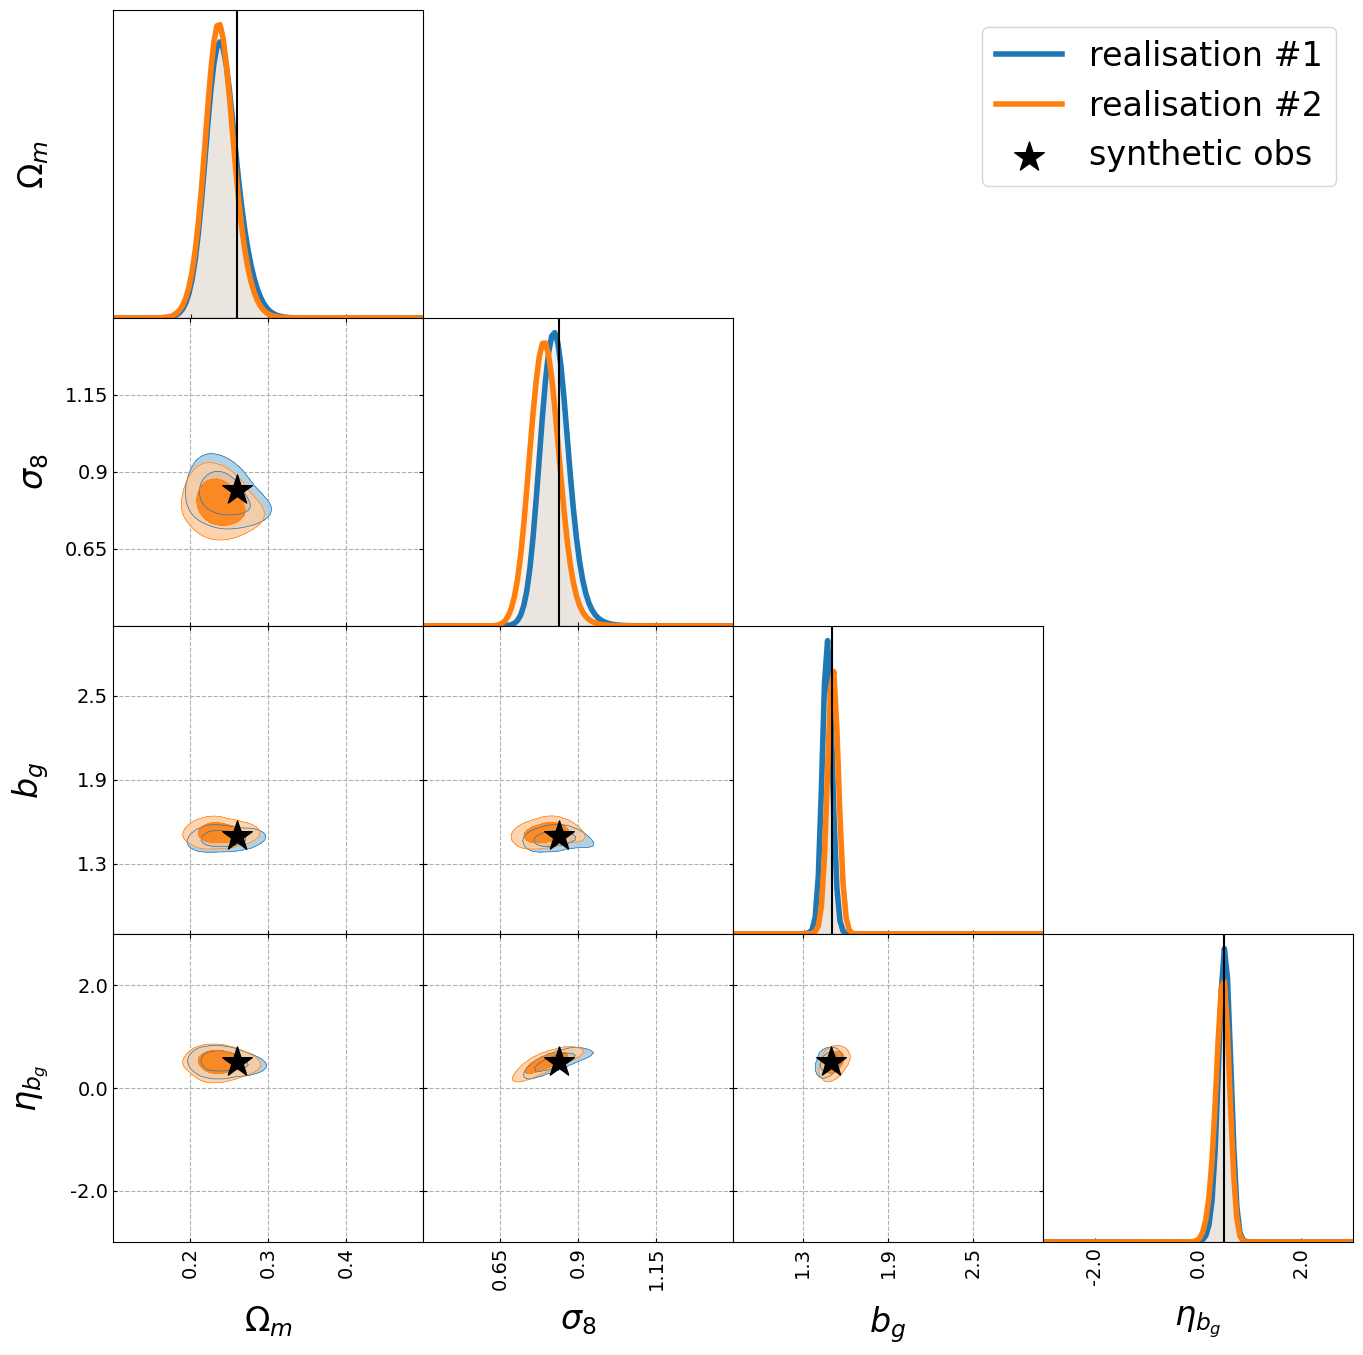

In [19]:
chains = [
    np.load(os.path.join(base_dir, model_dir, f"chain_{label}.npy")) for label in labels
]

# legend_labels = [
#     "including survey sys",
#     "excluding survey sys",
# ]

legend_labels = [
    "realisation #1",
    "realisation #2",
]


plotting.plot_chains(
    chains, 
    params, 
    # out_dir=out_dir, 
    out_dir=None, 
    out_file=f"contours_{n_steps}_survey_sys.png",
    labels=legend_labels,
)